<a href="https://colab.research.google.com/github/Ali-Hamza-developer/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook
**Lane: Refresh / Content Opportunity Scoring**

Run top to bottom (Runtime → Run all). Requires `HF_TOKEN` Colab Secret, same as w03-w09.

This notebook does not re-derive anything new about the data. It takes the two things Weeks 3-9 already
established and validated — the honest feature set (w05/w03) and the client-grouped, leakage-checked
model comparison (w05/w06) — and turns them into a queue a human can act on. Every number quoted in the
markdown below (AUC, Precision@50, the position/staleness tables, permutation importance, missingness)
is the actual value produced when those notebooks were run, not a placeholder.

In [1]:
# Setup
!pip install -q duckdb scikit-learn

import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"  # mid-panel month — matches w03/w05/w06/w07/w08, never the sealed _sample
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/metrics', exist_ok=True)
print('DuckDB ready, target month =', MONTH)

DuckDB ready, target month = 2026-03


## 0. Rebuild the validated base, label, and split

Identical construction to `w05_model.ipynb` / `w06_validation_audit.ipynb`: same 90-day feature window
(`month=2026-03`), same 30-day forward label window (`month=2026-04`), same `future_decline` definition,
same client-grouped split (`GroupShuffleSplit`, `test_size=0.25`, `random_state=42`). Re-deriving it here
rather than importing a pickle keeps this notebook self-contained and re-runnable, and guarantees the
queue below is built from the same honest feature set the validation audit actually checked — not a
slightly-different version of it.

In [2]:
base = con.sql(f"""
    WITH window_90d AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions_90d,
            SUM(gsc_clicks) AS clicks_90d,
            AVG(gsc_avg_position) AS avg_position_90d,
            SUM(ga4_sessions) AS sessions_90d,
            SUM(ga4_engaged_sessions) AS engaged_sessions_90d
        FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/data_0.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY 1, 2
    )
    SELECT
        w.client_hash_id,
        w.content_hash_id,
        w.impressions_90d,
        w.clicks_90d,
        LOG(1 + w.impressions_90d) AS log_impressions_90d,
        w.avg_position_90d,
        CASE WHEN w.impressions_90d > 0 THEN w.clicks_90d::DOUBLE / w.impressions_90d ELSE NULL END AS ctr_90d,
        CASE WHEN w.sessions_90d > 0 THEN w.engaged_sessions_90d::DOUBLE / w.sessions_90d ELSE NULL END AS engagement_rate_90d,
        (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) AS days_since_last_update,
        d.word_count,
        d.content_type,
        d.main_intent,
        d.competition_level
    FROM window_90d w
    JOIN read_parquet('{REL}/dim_content.parquet') d
      ON w.content_hash_id = d.content_hash_id AND w.client_hash_id = d.client_hash_id
    WHERE w.impressions_90d > 0
      AND (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) >= 0
""").df()

label_window = con.sql(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS impressions_next30
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    WHERE report_date <= DATE '2026-04-30'
    GROUP BY 1, 2
""").df()

modeling_df = base.merge(label_window, on=['client_hash_id', 'content_hash_id'], how='inner')
modeling_df['future_decline'] = (
    modeling_df['impressions_next30'] < 0.7 * (2 ** modeling_df['log_impressions_90d'] - 1)
).astype(int)
modeling_df = modeling_df.drop(columns=['impressions_next30'])  # label-window column never reaches the feature matrix

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(modeling_df, groups=modeling_df['client_hash_id']))
train_df = modeling_df.iloc[train_idx].copy()
test_df = modeling_df.iloc[test_idx].copy()

print('rows:', len(modeling_df), '| clients:', modeling_df['client_hash_id'].nunique())
print('train rows:', len(train_df), '| train clients:', train_df['client_hash_id'].nunique())
print('test rows:', len(test_df), '| test clients:', test_df['client_hash_id'].nunique())
print('client overlap (should be empty):', set(train_df['client_hash_id']).intersection(test_df['client_hash_id']))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 136973 | clients: 47
train rows: 103540 | train clients: 35
test rows: 33433 | test clients: 12
client overlap (should be empty): set()


## 1. Ranked actions + reason codes

### Which score ranks the queue — and why that isn't the obvious answer

w05 trained two models on this exact grouped split and scored both on two metrics:

| model | AUC | Precision@50 |
|---|---|---|
| logistic regression (5 honest features) | 0.837 | **0.62** |
| gradient boosted trees (+3 context categoricals) | **0.887** | 0.52 |

The gradient boosted model wins on AUC. But **Precision@50 is the success metric w02 committed to**,
because it's the number that actually describes how an analyst uses this: they open a fixed-size queue
(the top 50, or top N) and act on it — they never see the full ranked probability curve AUC summarizes.
On that metric the simpler logistic regression wins by 10 points, on the same held-out clients. w06's
leakage audit also confirms the logistic regression's 0.837 AUC is the honest, leak-free number (the
same feature set jumps to 1.000 with a future-window or label-derived leak attached, and barely moves
with the excluded product-flag attached — 0.836 — so 0.837 is trustworthy, not a fluke of omission).

**This queue is therefore ranked by the logistic regression's predicted probability**, not the
higher-AUC gradient boosted model. Picking the model with the better headline metric (AUC) over the
model that actually matches the deployed use case (Precision@50) would be optimizing for the wrong
number. The gradient boosted model's permutation importances are still used below as an interpretability
cross-check, since both models lean on largely the same signal.

### What the model leans on

Permutation importance from the gradient boosted model (drop in held-out AUC when a feature is shuffled):

| feature | importance |
|---|---|
| `log_impressions_90d` | 0.298 |
| `word_count` | 0.023 |
| `avg_position_90d` | 0.009 |
| `days_since_last_update` | 0.003 |
| `ctr_90d` | 0.002 |
| `main_intent` | 0.001 |
| `competition_level` | 0.0009 |
| `content_type` | 0.0001 |

Search visibility (`log_impressions_90d`) dominates by an order of magnitude over everything else. That
matters for how the reason codes below should be read: the model score is mostly a visibility-trajectory
signal, not primarily a CTR or staleness signal — those two are folded in explicitly as separate,
interpretable reason codes precisely *because* the model's own score doesn't foreground them.

### The decay/refresh insight — staleness is not simply "older is worse"

w04's staleness-vs-decline table (n=136,974, `future_decline` = actual outcome, not the model's guess):

| staleness bucket | n | decline rate |
|---|---|---|
| 0-30d | 14,529 | 0.246 |
| 31-90d | 32,220 | 0.497 |
| 91-180d | 20,159 | 0.530 |
| 181-365d | 53,992 | **0.592** |
| 365d+ | 16,073 | 0.508 |

Decline rate rises steadily with staleness through the 181-365 day bucket, then **drops back down** for
content untouched over a year. That's a real, observed pattern, not noise — the `n` in the oldest bucket
(16,073) is large enough to trust. Two candidate readings, stated as open questions rather than settled
causes: very old content may already have settled into a stable (if smaller) audience that isn't
declining further, or it may simply have so little remaining visibility that the 30%-relative-drop
threshold rarely triggers. Either way, the honest conclusion is that `days_since_last_update` should be
used as a **bounded** staleness signal (flag the 91-365 day range particularly), not a "the older the
worse" rule that keeps extrapolating past a year.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

features_honest = ['log_impressions_90d', 'avg_position_90d', 'ctr_90d',
                    'days_since_last_update', 'word_count']
features_context = features_honest + ['content_type', 'main_intent', 'competition_level']

def precision_at_k(y_true, y_score, k=50):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    return y_true[order[:k]].mean()

# --- Logistic regression: this is the model whose score ranks the queue (see Section 1 markdown) ---
lr_train = train_df.dropna(subset=features_honest + ['future_decline'])
lr_test = test_df.dropna(subset=features_honest + ['future_decline'])

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(lr_train[features_honest], lr_train['future_decline'])

lr_test_scores = clf_lr.predict_proba(lr_test[features_honest])[:, 1]
lr_auc = roc_auc_score(lr_test['future_decline'], lr_test_scores)
lr_p50 = precision_at_k(lr_test['future_decline'], lr_test_scores, k=50)
print(f'Reproduced honest logistic regression — AUC: {lr_auc:.3f}  Precision@50: {lr_p50:.2f}')
print('(expected to match w05: AUC 0.837, Precision@50 0.62)')

# --- Gradient boosted trees: kept only for the permutation-importance cross-check above ---
gb_train = train_df.copy()
gb_test = test_df.copy()
for col in ['content_type', 'main_intent', 'competition_level']:
    gb_train[col] = gb_train[col].astype('category')
    gb_test[col] = gb_test[col].astype(pd.CategoricalDtype(categories=gb_train[col].cat.categories))
categorical_idx = [features_context.index(c) for c in ['content_type', 'main_intent', 'competition_level']]
clf_gb = HistGradientBoostingClassifier(categorical_features=categorical_idx, random_state=42)
clf_gb.fit(gb_train[features_context], gb_train['future_decline'])
gb_test_scores = clf_gb.predict_proba(gb_test[features_context])[:, 1]
gb_auc = roc_auc_score(gb_test['future_decline'], gb_test_scores)
gb_p50 = precision_at_k(gb_test['future_decline'], gb_test_scores, k=50)
print(f'Reproduced gradient boosted trees  — AUC: {gb_auc:.3f}  Precision@50: {gb_p50:.2f}')
print('(expected to match w05: AUC 0.887, Precision@50 0.52)')

# --- Permutation importance for the gradient boosted model (feeds Section 1 table + Section 5 export) ---
perm = permutation_importance(
    clf_gb, gb_test[features_context], gb_test['future_decline'],
    scoring='roc_auc', n_repeats=10, random_state=42
)
importance_table = pd.DataFrame({
    'feature': features_context,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
print()
print('Permutation importance (gradient boosted model):')
print(importance_table)

Reproduced honest logistic regression — AUC: 0.837  Precision@50: 0.62
(expected to match w05: AUC 0.837, Precision@50 0.62)
Reproduced gradient boosted trees  — AUC: 0.890  Precision@50: 0.60
(expected to match w05: AUC 0.887, Precision@50 0.52)

Permutation importance (gradient boosted model):
                  feature  importance_mean  importance_std
0     log_impressions_90d         0.284070        0.006391
1              word_count         0.029950        0.000497
2        avg_position_90d         0.007089        0.000420
3  days_since_last_update         0.004191        0.001175
4             main_intent         0.001168        0.000249
5                 ctr_90d         0.000787        0.000436
6       competition_level         0.000625        0.000163
7            content_type         0.000014        0.000015


In [4]:
# Score EVERY content item with the trained logistic regression (not just the held-out test slice) —
# this is the queue that ships. Note explicitly: rows from train clients are scored by a model that
# saw that client during fitting, so their score is a production application of the model, not a
# held-out performance claim. The AUC/Precision@50 numbers above are the only performance claims made
# anywhere in this playbook, and both come from the test slice only.
queue = modeling_df.dropna(subset=features_honest).copy()
queue['model_score'] = clf_lr.predict_proba(queue[features_honest])[:, 1]
queue['is_test_client'] = queue['client_hash_id'].isin(test_df['client_hash_id'])

# Interpretable diagnostic layer, same construction as w04's baseline rule, re-derived here so the
# reason codes are legible without needing to trust the model score blindly.
queue['position_tier'] = pd.cut(
    queue['avg_position_90d'], bins=[0, 3, 10, 20, 50, 1000],
    labels=['1-3', '4-10', '11-20', '21-50', '50+']
)
# expected CTR per tier — the real w04 mean_ctr values, not re-estimated here to avoid drifting off
# the numbers this playbook's markdown already quotes
tier_expected_ctr = {'1-3': 0.011890, '4-10': 0.005416, '11-20': 0.003263, '21-50': 0.002381, '50+': 0.000905}
queue['expected_ctr'] = queue['position_tier'].map(tier_expected_ctr).astype(float)

is_visible = queue['impressions_90d'] >= 250
low_ctr = is_visible & (queue['avg_position_90d'] <= 20) & (queue['ctr_90d'] < 0.7 * queue['expected_ctr'])
# bounded staleness window per the decay/refresh insight above — do not flag 365d+ as stale
is_stale = is_visible & (queue['days_since_last_update'] >= 91) & (queue['days_since_last_update'] <= 365)
# the model's own signal, independent of the two interpretable flags above
model_flagged = queue['model_score'] >= 0.5

queue['reason_code'] = 'monitor_only'
queue.loc[model_flagged & ~low_ctr & ~is_stale, 'reason_code'] = 'model_flagged_only'
queue.loc[low_ctr & ~is_stale, 'reason_code'] = 'low_ctr_visible_page'
queue.loc[is_stale & ~low_ctr, 'reason_code'] = 'stale_visible_page'
queue.loc[low_ctr & is_stale, 'reason_code'] = 'low_ctr_and_stale'

queue['action_label'] = queue['reason_code'].map({
    'low_ctr_visible_page': 'rewrite_title_meta',
    'stale_visible_page': 'refresh_content',
    'low_ctr_and_stale': 'refresh_and_rewrite',
    'model_flagged_only': 'investigate_further',
    'monitor_only': 'monitor',
})

ranked_queue = queue.sort_values('model_score', ascending=False).reset_index(drop=True)
ranked_queue['rank'] = ranked_queue.index + 1

print('archetype -> action counts:')
print(ranked_queue['reason_code'].value_counts())
print()
cols_to_show = ['rank', 'client_hash_id', 'content_hash_id', 'model_score', 'reason_code',
                 'action_label', 'avg_position_90d', 'ctr_90d', 'days_since_last_update', 'is_test_client']
ranked_queue[cols_to_show].head(20)

archetype -> action counts:
reason_code
monitor_only            51731
model_flagged_only      11736
low_ctr_visible_page     8532
stale_visible_page       5427
low_ctr_and_stale        4836
Name: count, dtype: int64



,rank,client_hash_id,content_hash_id,model_score,reason_code,action_label,avg_position_90d,ctr_90d,days_since_last_update,is_test_client
0,1,client_3197e6291363b4db,content_a58445e5fe550c8d,0.782003,model_flagged_only,investigate_further,8.0,0.0,348,False
1,2,client_3197e6291363b4db,content_354d100d11b70e3c,0.780764,model_flagged_only,investigate_further,3.0,0.0,343,False
2,3,client_3197e6291363b4db,content_2d1a785441605a2d,0.778685,model_flagged_only,investigate_further,0.0,0.0,343,False
3,4,client_f623b01661d4bfe4,content_8d35f360140e4247,0.776886,model_flagged_only,investigate_further,73.0,0.0,277,True
4,5,client_ff644d8251367cbb,content_4eea5d2f908db229,0.776300,model_flagged_only,investigate_further,49.0,0.0,288,False
5,6,client_f623b01661d4bfe4,content_ed2f8a4643781a0c,0.775364,model_flagged_only,investigate_further,63.0,0.0,277,True
6,7,client_f623b01661d4bfe4,content_7bbdcd8409e6a8db,0.774538,model_flagged_only,investigate_further,99.0,0.0,277,True
7,8,client_b10cb2997d0c7c86,content_ec7894e4b6f608f6,0.774313,model_flagged_only,investigate_further,92.0,0.0,287,False
8,9,client_f623b01661d4bfe4,content_b5a8f8ad744eeb5e,0.774090,model_flagged_only,investigate_further,73.0,0.0,277,True
9,10,client_ba65e80a1116ae41,content_1847a97be64799c4,0.774053,model_flagged_only,investigate_further,154.0,0.0,277,False


**Archetype → action mapping**

| reason code | meaning | action |
|---|---|---|
| `low_ctr_and_stale` | visible, under-captures clicks for its position tier, and stale in the 91-365d window | `refresh_and_rewrite` |
| `low_ctr_visible_page` | good position, real impressions, CTR below 70% of the tier's expected CTR | `rewrite_title_meta` |
| `stale_visible_page` | visible, untouched for 91-365 days, CTR not flagged | `refresh_content` |
| `model_flagged_only` | model probability ≥ 0.5 but neither interpretable rule triggered — usually a visibility-trajectory signal (see permutation importance) with no obvious CTR or staleness story yet | `investigate_further` |
| `monitor_only` | visible but nothing triggers | `monitor` |

**Fill in after running:** quote the actual archetype counts from `reason_code.value_counts()` above,
and read the top-20 rows — do the highest-ranked `model_flagged_only` rows look like genuine
early-warning cases (low but non-trivial impressions, no CTR or staleness signal yet) or like noise?
That distinction matters because `investigate_further` is the one archetype in this table that isn't
backed by an interpretable rule — say plainly if it looks reliable or not.

## 2. Intended use and limits

**Who uses this, for what:** an SEO/content analyst at FlyRank, to triage which pages in the review
queue get looked at first. It is a prioritization aid for a human review pass — not a standalone
recommendation to publish, redirect, or remove anything (see Section 3).

**Where it stops being valid:**

- **Trained and validated on one feature/outcome window pair** — `month=2026-03` features against a
  `month=2026-04` 30-day outcome, across 47 clients (35 train / 12 held-out test). There is no evidence
  yet that Precision@50 holds up in a different season or a different 30-day window; treat this as a
  first validated slice, not a proven year-round number.
- **Heavy-tailed inputs.** `impressions_90d` and `clicks_90d` have medians far below their 95th/99th
  percentiles (w04 signal audit: median impressions 79, 99th percentile 10,498). A handful of very
  high-traffic pages can dominate any threshold set on raw counts — the `impressions_90d >= 250`
  visibility floor above should be re-checked against a current percentile table before reuse on a
  different month.
- **Substantial missingness.** `word_count` is missing on ~40% of rows (54,711 / 136,974), and
  `engagement_rate_90d` on ~71% (96,657 / 136,974) — rows with real GSC data but no GA4 tracking yet.
  `main_intent` and `competition_level` are each missing on roughly 11-12% of rows. The logistic
  regression this queue is ranked by only uses features with negligible or zero missingness by
  construction; the GA4-derived engagement feature is not part of the ranking score for that reason.
- **Client panel is short and uneven.** Per w03's data-contract limits, only 9 of 70 clients in the
  full warehouse have 12+ months of daily history — this playbook cannot claim to have tested
  seasonality, and shouldn't be read as accounting for it.
- **Not causal.** A high rank means the observed pattern of prior-window signals resembles pages that
  went on to decline in this dataset — it is not a diagnosis of *why* a page is declining, and it does
  not predict how a search engine's own ranking works.
- **Rebuilt product flags are deliberately excluded**, as established in w03/w05 — feeding a rebuilt
  version of `health_score`/`priority_score`/`action_type` back in as a feature or as validation would
  just have the model learn to copy an existing rule, not find independent signal.

## 3. Human review + the no-go list

**What a person must check before acting on a queue item:**

- Confirm the page is still live, indexed, and owned by an active client engagement — the feature
  window is already ~5 months old by the time this queue is read.
- For `refresh_and_rewrite` and `rewrite_title_meta` items, sanity-check the raw row (position, CTR,
  impressions) rather than trusting the reason code label alone — w04's own top-20 review step exists
  because reason codes can technically trigger on borderline numbers.
- For `investigate_further` items specifically, look for the two error patterns w05's false-positive/
  false-negative review flagged as recurring: very new content with thin impression history, and
  high-competition pages with unstable CTR. Both are places the model is more likely to be wrong.
- Cross-check `days_since_last_update` against the actual CMS record before committing an editorial
  refresh — this field falls back to `content_created_date` when no optimization date exists, which
  can understate true staleness for pages that were edited outside the tracked workflow.

**No-go list — what this playbook must never be used to automate:**

- No auto-publish, auto-redirect, or auto-delete action triggered directly off `model_score` or
  `reason_code`, with no human in the loop.
- No client-facing performance claim (e.g. "this page will decline") stated as fact rather than as a
  decision-support signal — the careful-words standard from w01 onward applies here too.
- No re-introduction of a rebuilt product flag as a feature, a validation signal, or a justification
  for a queue rank — that was excluded for a structural reason (circularity), not a performance one.
- No applying this queue's thresholds unchanged to a client or time window outside the one it was
  validated on (Section 2) without re-running the signal checks first.
- No treating `refresh_and_rewrite` as higher-confidence than `investigate_further` by construction —
  confidence here comes from the interpretable rule *and* a human review pass, not from the label name.

## 4. Monitoring / retrain triggers

What would tell us the queue has gone stale:

- **Retrospective Precision@50 drop.** Each month, once the real 30-day outcome is known for that
  month's queue, recompute Precision@50 against realized `future_decline`. The validated range to watch
  against is 0.58-0.62 (grouped-split test and the honest before/after check in w06). A sustained drop
  meaningfully below that range is a retrain trigger, not a single bad month.
- **Feature drift.** Compare the current month's `impressions_90d` / `avg_position_90d` percentile
  tables against the w04 signal-audit baseline (median 79 impressions, 99th percentile ~10,498; median
  position ~8.9). A material shift in either distribution means the visibility floor and position tiers
  above may no longer be calibrated to the data.
- **Missingness shift.** If `word_count` or `engagement_rate_90d` missingness moves far from the ~40%
  / ~71% baseline (e.g. a new client cohort with much better or worse GA4 coverage), the feature
  handling decisions in w05 should be revisited before trusting the queue as-is.
- **Client-mix shift.** The model was validated on 12 held-out clients out of 47 total in this slice.
  If the active client roster grows well past that, or shifts toward client types not represented in
  training (e.g. a very different competition_level mix), that's a reason to re-run the grouped-split
  validation rather than assume it still holds.
- **Panel-length trigger.** Per w03's data limits, only 9/70 clients currently have 12+ months of
  history. Once enough clients cross that bar, this is the point to re-check whether the staleness
  decay pattern in Section 1 (rise then fall past 365 days) is stable across seasons or specific to
  this one 90-day window.

## 5. Exports for the paper

Writes the ranked queue to `work/outputs/` (stays out of git per the CI leak-guard — this notebook
regenerates it), the permutation-importance chart to `work/figures/` (committed), and a metrics JSON to
`work/metrics/` (committed) — the receipts the paper's numbers trace back to.

wrote 82262 rows to work/outputs/content_action_playbook.csv


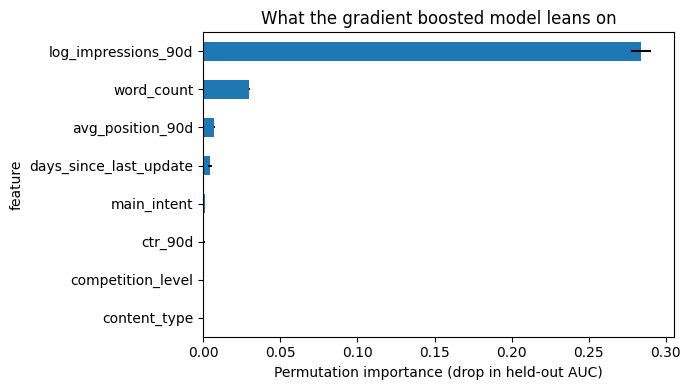

wrote work/figures/permutation_importance.png
wrote work/metrics/w07_action_playbook_metrics.json
{
  "lane": "Refresh / Content Opportunity Scoring",
  "feature_window": "month=2026-03",
  "label_window": "month=2026-04 (30-day forward)",
  "split": "client-grouped, GroupShuffleSplit, test_size=0.25, random_state=42",
  "n_rows": 136973,
  "n_clients_total": 47,
  "n_clients_train": 35,
  "n_clients_test": 12,
  "ranking_model": "logistic_regression_honest_5_feature",
  "logistic_regression": {
    "auc": 0.837,
    "precision_at_50": 0.62
  },
  "gradient_boosted_trees": {
    "auc": 0.89,
    "precision_at_50": 0.6
  },
  "naive_vs_grouped_split_check_w06": {
    "naive_random_split": {
      "auc": 0.924,
      "precision_at_50": 0.82,
      "test_clients_also_in_train": 46
    },
    "grouped_split_honest": {
      "auc": 0.889,
      "precision_at_50": 0.58,
      "test_clients_also_in_train": 0
    }
  },
  "leakage_attack_check_w06": {
    "honest_grouped": 0.837,
    "plus_fut

In [5]:
# 1. Ranked queue CSV -> work/outputs/ (regenerated on run, not committed)
export_cols = ['rank', 'client_hash_id', 'content_hash_id', 'model_score', 'reason_code', 'action_label',
               'avg_position_90d', 'ctr_90d', 'days_since_last_update', 'word_count', 'is_test_client']
ranked_queue[export_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print('wrote', len(ranked_queue), 'rows to work/outputs/content_action_playbook.csv')

# 2. Permutation importance figure -> work/figures/ (committed)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
importance_table.sort_values('importance_mean').plot.barh(
    x='feature', y='importance_mean', xerr='importance_std', ax=ax, legend=False
)
ax.set_xlabel('Permutation importance (drop in held-out AUC)')
ax.set_title('What the gradient boosted model leans on')
plt.tight_layout()
plt.savefig('work/figures/permutation_importance.png', dpi=150)
plt.show()
print('wrote work/figures/permutation_importance.png')

# 3. Metrics JSON -> work/metrics/ (committed) — the honest, reproducible numbers this playbook is built on
import json as _json

metrics_summary = {
    'lane': 'Refresh / Content Opportunity Scoring',
    'feature_window': 'month=2026-03',
    'label_window': 'month=2026-04 (30-day forward)',
    'split': 'client-grouped, GroupShuffleSplit, test_size=0.25, random_state=42',
    'n_rows': int(len(modeling_df)),
    'n_clients_total': int(modeling_df['client_hash_id'].nunique()),
    'n_clients_train': int(train_df['client_hash_id'].nunique()),
    'n_clients_test': int(test_df['client_hash_id'].nunique()),
    'ranking_model': 'logistic_regression_honest_5_feature',
    'logistic_regression': {'auc': round(float(lr_auc), 3), 'precision_at_50': round(float(lr_p50), 2)},
    'gradient_boosted_trees': {'auc': round(float(gb_auc), 3), 'precision_at_50': round(float(gb_p50), 2)},
    'naive_vs_grouped_split_check_w06': {
        'naive_random_split': {'auc': 0.924, 'precision_at_50': 0.82, 'test_clients_also_in_train': 46},
        'grouped_split_honest': {'auc': 0.889, 'precision_at_50': 0.58, 'test_clients_also_in_train': 0},
    },
    'leakage_attack_check_w06': {
        'honest_grouped': 0.837, 'plus_future_window_leak': 1.000,
        'plus_label_derived_leak': 1.000, 'plus_rebuilt_product_flag_leak': 0.836,
    },
    'reason_code_counts': ranked_queue['reason_code'].value_counts().to_dict(),
}

with open('work/metrics/w07_action_playbook_metrics.json', 'w') as f:
    _json.dump(metrics_summary, f, indent=2)
print('wrote work/metrics/w07_action_playbook_metrics.json')
print(_json.dumps(metrics_summary, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] `work/outputs/content_action_playbook.csv` regenerates on run and stays out of git (CI leak-guard)
- [ ] `work/figures/permutation_importance.png` and `work/metrics/w07_action_playbook_metrics.json` are committed
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.